In [1]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import pandas as pd
import ast
from pprint import pprint
import matplotlib.pyplot as plt
import pyproj
from shapely.geometry import LineString
from collections import defaultdict
import math
from haversine import haversine, Unit, inverse_haversine
from matplotlib.colors import to_rgb, to_hex

# mappymatch imports
from mappymatch.constructs.trace import Trace
from mappymatch.maps.nx.nx_map import NxMap
from mappymatch.matchers.lcss.lcss import LCSSMatcher
pd.set_option('future.no_silent_downcasting', True)

## Graph Creation

In [2]:
# Define your bounding box manually
north = 41.188771290159195
south = 41.13090363866696
west  = -8.699966476287791
east  = -8.559738123284369


bbox = (west, south, east, north)
# Fetch network from the bounding box
G_bbox = ox.graph_from_bbox(
    bbox=bbox,
    network_type="drive",   # can be 'drive', 'walk', etc.
    simplify=True,
)

# Project to local CRS (UTM Zone 29N, or Mercator 3857)
porto_crs = 3857
G = ox.project_graph(G_bbox, to_crs=porto_crs)

# Add geometry to edges that don't have it
for u, v, k, data in G.edges(keys=True, data=True):
    if 'geometry' not in data:
        point_u = (G.nodes[u]['x'], G.nodes[u]['y']) # x is long, y is lat
        point_v = (G.nodes[v]['x'], G.nodes[v]['y'])
        data['geometry'] = LineString([point_u, point_v])
        

In [3]:
# Create the smaller dataset

# traj_df = pd.read_csv("train.csv", nrows=15, index_col=0)
# traj_df.to_csv( "train_15.csv")

In [4]:
# Read trajectory data of the form long, lat
traj_df = pd.read_csv("train_15.csv", index_col=0)

polylines = traj_df["POLYLINE"].to_numpy()
trajectories = []

for line in polylines:
    traj = ast.literal_eval(line)  # list of (lon, lat)
    trajectories.append(traj)


# Unclean trips, used for plotting
trips = [  gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in traj],crs="EPSG:4326"  # convert from lat/long
        ).to_crs(porto_crs) 
    for traj in trajectories]


# Vivid colors for trips and routes
vivid_colors = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#ffff33",  # yellow
    "#a65628",  # brown
    "#f781bf",  # pink
    "#999999",  # gray
    "#66c2a5",  # teal
    "#fc8d62",  # salmon
    "#8da0cb",  # light blue
    "#000000",  # black
    "#a6d854",  # lime
    "#ffd92f"   # gold
]

## Unclean Trips

### Plotting unclean GPS Trajectory data in this section

In [5]:
# Base graph plot
fig, ax = ox.plot_graph(
    G,
    figsize=(15,9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# Plot each trajectory
for index, traj in enumerate(trips):
    x, y = traj.geometry.x, traj.geometry.y
    color = vivid_colors[index % len(vivid_colors)]  # wrap around if >15 trips
    ax.plot(
        x, y,
        color=color,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.3,
        linewidth=1.5,
        alpha=0.9,
        zorder=3,
        label=f"Trip {index+1}"
    )

# Legend and title
ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

ax.set_title("First 15 Porto Trips on Road Network", fontsize=14, y=0.95)
fig.savefig("LCSS_Images/unclean_gps_plot_part_2.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.close(fig)


### MapMatching Unclean Trips to routes in this section

In [6]:

matcher = LCSSMatcher( NxMap(G),
                      distance_epsilon  = 100,              # deafult = 50
                      similarity_cutoff  =0.9,                # default = 0.9
                      cutting_threshold=10,                 # default = 10
                      random_cuts=0,                        # default = 0
                      distance_threshold = 500)             # default = 10000, 


routes = []

for index, traj in enumerate(trips): 
    print(f"---- Processing trips {index+1}/{len(trips)} ----")

    # Create Trace directly from GeoDataFrame (in EPSG:4326 for Valhalla)
    trace = Trace.from_geo_dataframe(traj, xy=False)

    # Perform matching
    match_result = matcher.match_trace(trace)

    path = [ route.geom for route in match_result.path]
    routes.append(path)

    print(f"Matched to {len(routes[-1])} road segments")

---- Processing trips 1/15 ----
Matched to 21 road segments
---- Processing trips 2/15 ----
Matched to 29 road segments
---- Processing trips 3/15 ----
Matched to 8 road segments
---- Processing trips 4/15 ----
Matched to 75 road segments
---- Processing trips 5/15 ----
Matched to 44 road segments
---- Processing trips 6/15 ----
Matched to 39 road segments
---- Processing trips 7/15 ----
Matched to 61 road segments
---- Processing trips 8/15 ----
Matched to 29 road segments
---- Processing trips 9/15 ----
Matched to 55 road segments
---- Processing trips 10/15 ----
Matched to 45 road segments
---- Processing trips 11/15 ----
Matched to 19 road segments
---- Processing trips 12/15 ----
Matched to 64 road segments
---- Processing trips 13/15 ----
Matched to 38 road segments
---- Processing trips 14/15 ----
Matched to 43 road segments
---- Processing trips 15/15 ----
Matched to 37 road segments


### Plotting Unclean Routes

In [7]:
# Prepare route geometries
routes_edges = []
for route in routes:
    xx = [x for link in route for x in link.xy[0]]
    yy = [y for link in route for y in link.xy[1]]
    routes_edges.append([xx, yy])


# --- Plot base OSM graph ---

fig, ax = ox.plot_graph(
    G,
    figsize=(15,9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# --- Plot matched routes ---
for index, (xx, yy) in enumerate(routes_edges):
    color = vivid_colors[index % len(vivid_colors)]
    ax.plot(xx, yy, color=color, linewidth=1.5, alpha=0.9, zorder=3, label=f"Route {index+1}")

# --- Styling ---
ax.set_title("Matched Routes on Road Network", fontsize=14, y=0.95)
ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")

# --- Save figure ---
fig.savefig("LCSS_Images/unclean_routes_part_4.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)


## Clean Trips

### Cleaning Trajectories

In this section the trajectories are cleaned manually and mapmatching is performed using these cleaned trajectories

[334.78068752629883,
 46.04539579238942,
 93.40629724853859,
 62.830855697025456,
 126.4092830271251,
 79.85073398115833,
 225.48592874768676,
 283.0638777764236,
 258.60875224316095,
 288.98227820125476,
 264.31805885423324,
 298.18986553670396,
 246.7476165696003,
 120.91220375468964,
 218.240093330197,
 266.1359436893703,
 188.65894955224033,
 49.356442349694305,
 28.902713118311055,
 186.5188476445836,
 251.191634875059,
 273.23933723460596,
 290.45997780032843,
 301.73149904186295,
 210.8053361759773,
 213.93513710659457,
 265.86567657769996,
 240.21397548646686,
 99.15382530127484,
 37.08079541593947,
 5.936238387909034,
 5.380821141807827,
 6.322172672444729,
 5.629025714092012,
 5783.6285707302595,
 342.32762556191244,
 6142.703663869037,
 63.05919024028011,
 2.8145111287814877,
 5.33642723040168,
 85.83955587208337,
 87.36704857510928,
 28.901816821376446,
 139.79677843035282,
 105.38482603077581,
 154.3424931319138,
 104.37587997839704,
 21.385243823328405,
 95.1505378469372,

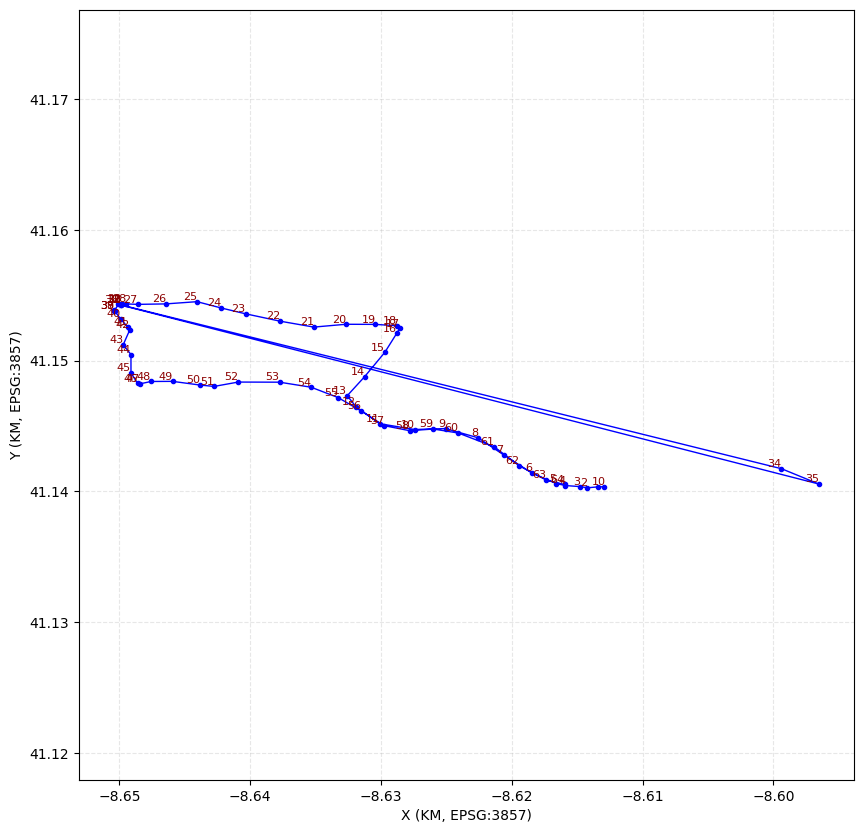

In [8]:
""" 
This code block visualizes a particular trajectory
"""

particular_traj = trajectories[2]
# compute_distances from previous popints, treat lat as x and long as y

rel_distances = []
for i in range(len(particular_traj[1:])):
    rel_distances.append(haversine(particular_traj[i], particular_traj[i-1], Unit.METERS))

pprint(rel_distances)

# Plot the line
plt.figure(figsize=(10,10))
x, y = zip(*particular_traj)
plt.plot(x, y, '-o', markersize=3, linewidth=1, color='blue')

# Annotate each point with its index
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, str(i), fontsize=8, ha='right', va='bottom', color='darkred')

# Styling
plt.axis('equal')
plt.xlabel("X (KM, EPSG:3857)")
plt.ylabel("Y (KM, EPSG:3857)")
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()


In [9]:
"""
Based on the results of previous section some outlier points are manually pruned. 
"""
trajectories[2] = [pt for i, pt in enumerate(trajectories[2]) if i not in {34,35}]
trajectories[3] = [pt for i, pt in enumerate(trajectories[3]) if i not in {15,16,17,18}]



Nearest nodes: 1771990365 2352439937
No edge exists. Adding a two-way virtual link.
Two-way virtual road added successfully.


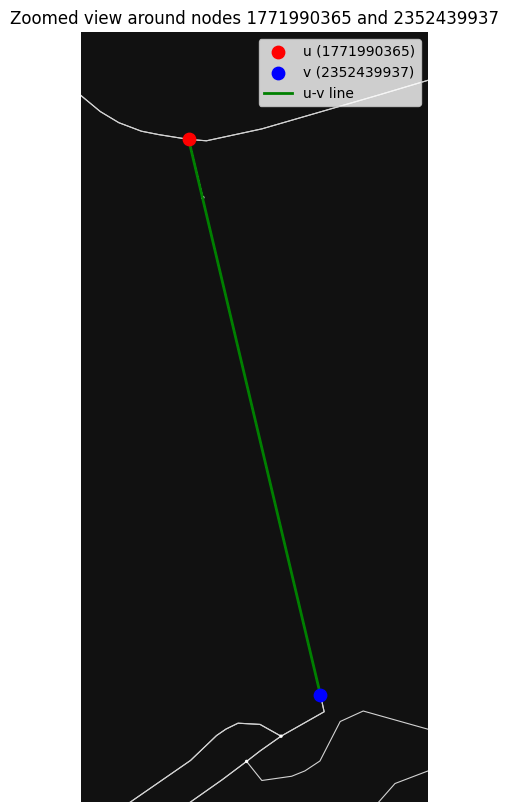

In [10]:
"""
Trip 10 uses a road link that is not part of the network, so here we add that link manually.
"""
# These points were obtained from the previous visualizing trajectory section
p1 = trajectories[9][3]
p2 = trajectories[9][4]

# Projecting lat/long to porto_crs
transformer = pyproj.Transformer.from_crs("EPSG:4326", porto_crs, always_xy=True)
x1, y1 = transformer.transform(*p1)
x2, y2 = transformer.transform(*p2)

# Find nearest nodes in the projected graph
u = ox.distance.nearest_nodes(G, X=x1, Y=y1)
v = ox.distance.nearest_nodes(G, X=x2, Y=y2)

print("Nearest nodes:", u, v)

# Check and add virtual edge if missing
if G.has_edge(u, v) or G.has_edge(v, u):
    print("An edge already exists between these nodes.")
else:
    print("No edge exists. Adding a two-way virtual link.")

    # Geometry for both directions
    geom_uv = LineString([(G.nodes[u]['x'], G.nodes[u]['y']),
                          (G.nodes[v]['x'], G.nodes[v]['y'])])
    geom_vu = LineString(list(geom_uv.coords)[::-1])

    # Edge length (in projected CRS)
    length = geom_uv.length

    # Edge data (two-way)
    edge_data_uv = {
        "osmid": -1,              # placeholder ID
        "highway": "virtual",
        "length": length,
        "geometry": geom_uv,
        "oneway": True,            # explicit one-way (forward)
        "two_way": True            # new marker to indicate originally two-way
    }

    edge_data_vu = {
        **edge_data_uv,
        "geometry": geom_vu,
    }

    # Add both directed edges
    G.add_edge(u, v, **edge_data_uv)
    G.add_edge(v, u, **edge_data_vu)

    print("Two-way virtual road added successfully.")



# Plot base graph (same as yours)
fig, ax = ox.plot_graph(
    G,
    figsize=(15, 10),
    node_size=6,
    node_color="white",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# Extract node coordinates
x_u, y_u = G.nodes[u]['x'], G.nodes[u]['y']
x_v, y_v = G.nodes[v]['x'], G.nodes[v]['y']

# Plot u (red) and v (blue)
ax.scatter([x_u], [y_u], c='red', s=80, zorder=5, label=f'u ({u})')
ax.scatter([x_v], [y_v], c='blue', s=80, zorder=5, label=f'v ({v})')

# Optional: line between them (green)
ax.plot([x_u, x_v], [y_u, y_v], c='green', lw=2, zorder=4, label='u-v line')

# Massive zoom: adjust limits to tightly focus on both points
pad = 50  # meters of padding, adjust as needed (smaller = tighter zoom)
minx, maxx = min(x_u, x_v) - pad, max(x_u, x_v) + pad
miny, maxy = min(y_u, y_v) - pad, max(y_u, y_v) + pad
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add legend and title
ax.legend()
ax.set_title(f"Zoomed view around nodes {u} and {v}", fontsize=12)

plt.show()


## Plotting Clean Trips

In [11]:
# Update trips to GeoDataSeries in same crs as porto_crs
trips = [  gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in traj],crs="EPSG:4326"  # convert from lat/long
        ).to_crs(porto_crs) 
    for traj in trajectories]

In [12]:
# Base graph plot
fig, ax = ox.plot_graph(
    G,
    figsize=(15,9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.6,
    show=False,
    close=False,
)

# Plot each trajectory
for i, traj in enumerate(trips):
    x, y = traj.geometry.x, traj.geometry.y
    color = vivid_colors[i % len(vivid_colors)]  # wrap around if >15 trips
    ax.plot(
        x, y,
        color=color,
        marker="o",
        markersize=4,
        markeredgecolor="black",
        markeredgewidth=0.3,
        linewidth=2.5,
        alpha=0.9,
        zorder=3,
        label=f"Trip {i+1}"
    )

# Legend and title
ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

ax.set_title("First 15 Porto Trips on Road Network", fontsize=14, y=0.95)
fig.tight_layout()
fig.savefig("LCSS_Images/cleaned_gps_plot_part_2.png", dpi=300, bbox_inches="tight", pad_inches=0)

plt.close(fig)


### MapMatching Clean Trips to routes in this section

In [13]:
# Collecting the output of map matching algorithm
# routes are a sequence of road segments that best fit the gps points, this is used in part 5.1 and part 4
# matched_dfs contain road segments each of which matches to a GPS point, used in part 5.2
# Note that len(routes[i]) >= len(matched_dfs[i]) because not each road link correponds to a gps point
# If a car moves too fast on a road link, between the gps collection, then no gps coordinate would be matched to that road link.
# So this road link wont appear in the matched_dfs but will appear in the route.


matcher = LCSSMatcher( NxMap(G),
                      distance_epsilon  = 100,              # deafult = 50
                      similarity_cutoff  =0.9,                # default = 0.9
                      cutting_threshold=10,                 # default = 10
                      random_cuts=0,                        # default = 0
                      distance_threshold = 500)             # default = 10000, 

routes = []
matches_dfs = []

for i, trip in enumerate(trips): 
    print(f"---- Processing trips {i+1}/{len(trips)} ----")

    # Create Trace directly from GeoDataFrame (already in EPSG:3857)
    trace = Trace.from_geo_dataframe(trip, xy=False)  

    # Perform matching
    match_result = matcher.match_trace(trace)
    

    # Store per-coordinate matches for inspection
    matches_dfs.append(match_result.matches_to_dataframe())

    # Extract the path, ie the list of routes
    # path is a sequence of road links, each of which stores id and geom, 
    # weonly store geom
    path = [ route for route in match_result.path]
    routes.append(path)

    print(f"Matched to {len(routes[-1])} road segments")


---- Processing trips 1/15 ----
Matched to 21 road segments
---- Processing trips 2/15 ----
Matched to 29 road segments
---- Processing trips 3/15 ----
Matched to 8 road segments
---- Processing trips 4/15 ----
Matched to 38 road segments
---- Processing trips 5/15 ----
Matched to 44 road segments
---- Processing trips 6/15 ----
Matched to 39 road segments
---- Processing trips 7/15 ----
Matched to 61 road segments
---- Processing trips 8/15 ----
Matched to 29 road segments
---- Processing trips 9/15 ----
Matched to 55 road segments
---- Processing trips 10/15 ----
Matched to 18 road segments
---- Processing trips 11/15 ----
Matched to 19 road segments
---- Processing trips 12/15 ----
Matched to 64 road segments
---- Processing trips 13/15 ----
Matched to 38 road segments
---- Processing trips 14/15 ----
Matched to 43 road segments
---- Processing trips 15/15 ----
Matched to 37 road segments


#### Accounting for loop

In [14]:
# Trajectory 3 has a loop, so it needs to be dealt separately

particular_traj = trajectories[2]
mid_pont = 32
traj_first = particular_traj[:mid_pont]
traj_second = particular_traj[mid_pont:]


# Update trips to GeoDataSeries in same crs as porto_crs
particular_trips = [  gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in traj],crs="EPSG:4326"  # convert from lat/long
        ).to_crs(porto_crs) 
    for traj in [traj_first, traj_second]]

particular_routes = []
particular_matched_df = []

for i, trip in enumerate(particular_trips): 
    print(f"---- Processing trips {i+1}/{len(particular_trips)} ----")

    # Create Trace directly from GeoDataFrame (already in EPSG:3857)
    trace = Trace.from_geo_dataframe(trip, xy=False)  

    # Perform matching
    match_result = matcher.match_trace(trace)
    

    # Store per-coordinate matches for inspection
    particular_matched_df.append(match_result.matches_to_dataframe())

    # Extract the path, ie the list of routes
    # path is a sequence of road links, each of which stores id and geom, 
    # weonly store geom
    path = [ route for route in match_result.path]
    particular_routes.append(path)

    print(f"Matched to {len(particular_routes[-1])} road segments")


# Combine the two matched DataFrames and paths
combined_df = pd.concat(particular_matched_df, ignore_index=True)
combined_route = particular_routes[0] + particular_routes[1]  # just concatenate lists

# Insert them back into the main lists at index 2
matches_dfs[2] = combined_df
routes[2] = combined_route



---- Processing trips 1/2 ----
Matched to 38 road segments
---- Processing trips 2/2 ----
Matched to 24 road segments


### Visualizing Cleaned Trips with their matched routes

In [15]:
def lighten_color(color, factor=0.6):
    """Lighten a color by a given factor (0=white, 1=original)."""
    rgb = to_rgb(color)
    light_rgb = [1 - factor*(1-c) for c in rgb]
    return to_hex(light_rgb)
batches = [
    [5,2],
    [1,3,10],
    [8,11,14],
    [12,9,13],
    [6,15,7,4]
]


# Prepare route geometries
routes_edges = []
for route in routes:
    xx = [x for link in route for x in link.geom.xy[0]]
    yy = [y for link in route for y in link.geom.xy[1]]
    routes_edges.append([xx, yy])
    
for batch in batches:
    fig, ax = ox.plot_graph(
        G,
        figsize=(15,9),
        bgcolor="white",
        node_size=6,
        node_color="lightgray",
        node_zorder=1,
        edge_color="lightgray",
        edge_linewidth=3,
        show=False,
        close=False,
    )
    
    batch_str = "-".join(str(b) for b in batch)
    
    # Collect all points for this batch to compute bounding box
    all_x, all_y = [], []
    
    for index in batch:
        index -= 1
        # Base color
        base_color = vivid_colors[index]
        # Slightly lighter for trip
        trip_color = lighten_color(base_color, factor=0.5)
        
        # Plot route (solid, thick) using routes_edges
        x, y = routes_edges[index]
        ax.plot(x, y, color=base_color, linewidth=2, alpha=0.8, zorder=4, label=f"Route {index+1}")
        all_x.extend(x)
        all_y.extend(y)
        
        # Plot trip (dashed, thinner, with markers)
        x_trip, y_trip = trips[index].geometry.x, trips[index].geometry.y
        ax.plot(
            x_trip, y_trip, color=trip_color, linestyle="--", linewidth=1,
            marker="o", markersize=4, markeredgecolor="black", markeredgewidth=0.3,
            alpha=0.9, zorder=5, label=f"Trip {index+1}"
        )
        all_x.extend(x_trip)
        all_y.extend(y_trip)
    
    # Compute bounding box with small padding (5%)
    pad_x = (max(all_x) - min(all_x)) * 0.05
    pad_y = (max(all_y) - min(all_y)) * 0.05
    ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
    ax.set_ylim(min(all_y) - pad_y, max(all_y) + pad_y)
    
    ax.set_title(f"Trips & Routes {batch_str}", fontsize=14, y=0.95)
    ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")
    
    # Save figure
    fig.savefig(f"LCSS_Images/matched_route_{batch_str}_part_4.png", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


## Analyzing routes

### Top 10 link counts

To count top 10 links, for each link in a route, its canonical nodes are stored , u = smaller, v = larger. This breaks some ties, but a lot more remain, thus to further resolve ties, longer links are prioritized.

In [16]:
# Count how many times each (u,v) edge appears
link_counts = defaultdict(int)
link_lengths = {}  # store length for tie-breaking
link_geoms = {}    # store geometry for plotting

for route in routes:  # each route is a list of Route objects
    for link in route:
        road_id = link.road_id
        u, v = sorted([road_id.start, road_id.end])  # canonical ordering
        link_counts[(u, v)] += 1

        # Store geometry if not already stored
        if (u, v) not in link_geoms:
            link_geoms[(u, v)] = link.geom
            link_lengths[(u, v)] = link.geom.length  # store length for tie-break

# Get top N edges with tie-breaking by length
N = 10
top_links = sorted(
    link_counts.items(),
    key=lambda x: (x[1], link_lengths[x[0]]),  # sort by count, then length
    reverse=True
)[:N]

print(f"Top {N} edges and counts (tie-broken by length):")
for i, ((u, v), count) in enumerate(top_links, 1):
    geom = link_geoms[(u, v)]
    length = link_lengths[(u, v)]
    print(f"{i}. Edge ({u}->{v}), Count: {count}, Length: {length:.2f}, "
          f"Geometry start/end: {geom.coords[0]} -> {geom.coords[-1]}")


# --- Plot base OSM graph (limited to bbox) ---
fig, ax = ox.plot_graph(
        G,
        figsize=(15,9),
        bgcolor="white",
        node_size=6,
        node_color="lightgray",
        node_zorder=1,
        edge_color="lightgray",
        edge_linewidth=3,
        show=False,
        close=False,
    )


# --- Plot top links ---
for i, (link, link_count) in enumerate(top_links):
    geom = link_geoms[link]  # this is a LineString
    x, y = geom.xy          # x and y are sequences of coordinates
    ax.plot(x, y, linewidth=3, alpha=0.8, zorder=4, label=f"Top Link {i+1}")


# --- Styling ---
ax.set_title("Top 15 Most Traversed Links on Road Network", fontsize=14, y=0.95)
ax.legend(loc="upper right",fontsize=8,frameon=True,facecolor="white",edgecolor="black")
fig.savefig("LCSS_Images/top_links_on_network_part_5_1.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)

Top 10 edges and counts (tie-broken by length):
1. Edge (2207418932->2262128243), Count: 5, Length: 94.41, Geometry start/end: (-958968.176573274, 5033169.722378109) -> (-959053.2580600873, 5033128.851185349)
2. Edge (111481288->2080756633), Count: 4, Length: 105.26, Geometry start/end: (-958843.5321394327, 5033224.222497076) -> (-958937.0405116992, 5033184.060595059)
3. Edge (2262128243->3392710660), Count: 4, Length: 51.42, Geometry start/end: (-959053.2580600873, 5033128.851185349) -> (-959099.8897947806, 5033107.225737871)
4. Edge (2080756633->2207418932), Count: 4, Length: 34.28, Geometry start/end: (-958937.0405116992, 5033184.060595059) -> (-958968.176573274, 5033169.722378109)
5. Edge (111467467->478821940), Count: 3, Length: 604.02, Geometry start/end: (-960326.1630414611, 5033714.515618773) -> (-960856.85644992, 5033926.794452886)
6. Edge (122549700->1788784885), Count: 3, Length: 524.84, Geometry start/end: (-959554.3627478933, 5033341.5163066285) -> (-959970.7533032055, 503

### Most slowest links

In [17]:

# Container: canonical_road -> [total_points, total_routes]
link_stats = defaultdict(lambda: [0, 0])
link_geoms = {}  # canonical_road -> LineString
N = 10

for traj_df in matches_dfs:
    # Count GPS points per road (canonical ordering)
    road_counts = defaultdict(float)
    
    for _, row in traj_df.iterrows():
        u, v = sorted([row['origin_junction_id'], row['destination_junction_id']])
        road = (u, v)
        
        # Store geometry if not already stored
        if road not in link_geoms:
            geom = row['geom']
            if not isinstance(geom, LineString):
                continue  # skip if not a LineString
            link_geoms[road] = geom
        
        # Increment counter for this GPS point
        road_counts[road] += 1.0

    # Subtract 0.5 from first and last road
    first_road = tuple(sorted([traj_df.iloc[0]['origin_junction_id'], traj_df.iloc[0]['destination_junction_id']]))
    last_road = tuple(sorted([traj_df.iloc[-1]['origin_junction_id'], traj_df.iloc[-1]['destination_junction_id']]))
    road_counts[first_road] -= 0.5
    road_counts[last_road] -= 0.5

    # Accumulate total points and route count
    for road, count in road_counts.items():
        link_stats[road][0] += count        # total GPS points
        link_stats[road][1] += 1            # number of routes

# Compute average GPS points per route for each road
avg_points_per_route = {
    road: total_points / total_routes
    for road, (total_points, total_routes) in link_stats.items()
}

# Get top N slowest roads (largest average points per route), tiebreak by road length
top_slowest = sorted(
    avg_points_per_route.items(),
    key=lambda x: (x[1], link_geoms[x[0]].length),  # sort by avg_points, then by length
    reverse=True
)[:N]

# Display results with geometry and length
for rank, (road, avg_points) in enumerate(top_slowest, 1):
    geom = link_geoms[road]
    length = geom.length  # length of the LineString
    print(f"{rank:2d}. Road {road}, avg GPS points per trajectory: {avg_points:.2f}, "
          f"Geometry start/end: {geom.coords[0]} -> {geom.coords[-1]}, Length: {length:.2f}")


#Plotting
fig, ax = ox.plot_graph(
    G,
    figsize=(15, 9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=3,
    show=False,
    close=False,
)

# --- Plot top slowest links ---
for i, (link_id, avg_points) in enumerate(top_slowest):
    geom = link_geoms[link_id]  # LineString
    x, y = geom.xy
    ax.plot(x, y, linewidth=3, alpha=0.8, zorder=4, label=f"Slow Link {i+1}")

# --- Styling ---
ax.set_title("Top 10 Slowest Links on Road Network (avg GPS points per route)", fontsize=14, y=0.95)
ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")

fig.savefig("LCSS_Images/top_slowest_links_part_5_2.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)



 1. Road (114320429, 1548073774), avg GPS points per trajectory: 10.50, Geometry start/end: (-954537.2155617385, 5034772.629857783) -> (-955026.6317030111, 5033938.576359998), Length: 1132.76
 2. Road (111481288, 2356350502), avg GPS points per trajectory: 9.50, Geometry start/end: (-958843.5321394327, 5033224.222497076) -> (-958910.8470355155, 5033388.729867615), Length: 177.75
 3. Road (428214955, 4612031737), avg GPS points per trajectory: 7.50, Geometry start/end: (-960100.217870998, 5036135.183985695) -> (-960103.2346291986, 5036245.888741841), Length: 110.75
 4. Road (1594598177, 1771990365), avg GPS points per trajectory: 7.00, Geometry start/end: (-958429.8466477469, 5033137.867961704) -> (-955861.3720366737, 5033475.707486777), Length: 2861.53
 5. Road (111459759, 111459776), avg GPS points per trajectory: 5.00, Geometry start/end: (-962462.7180282563, 5034255.628866757) -> (-961526.2762078053, 5034245.058804456), Length: 950.37
 6. Road (1143316499, 1143318399), avg GPS point